# Dataset Overvew
# Data Structure

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
df = pd.read_csv('COVID19_Patient_Risk_Analysis[1].csv')

In [3]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA_STATUS,HYPERTENSION_STATUS,CARDIOVASCULAR_STATUS,OBESITY_STATUS,RENAL_CHRONIC_STATUS,COMORBIDITY_COUNT,CRITICAL_CARE,RISK_CATEGORY,RECOVERY_STATUS,MISSING_VALUE_COUNT
0,2,4,2,1,9999-99-99,NaN,2.0,54.0,97,2.0,...,No,No,No,No,No,0,Unknown,Medium,Survived,4
1,2,12,1,1,9999-99-99,NaN,2.0,28.0,2,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4
2,2,4,2,1,9999-99-99,NaN,2.0,45.0,97,1.0,...,No,No,No,No,No,1,Unknown,Medium,Survived,4
3,1,12,2,1,9999-99-99,NaN,2.0,33.0,97,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4
4,1,12,1,1,9999-99-99,NaN,2.0,25.0,2,2.0,...,No,No,No,No,No,0,Unknown,Low,Survived,4


In [6]:
df.shape

(25000, 38)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   USMER                  25000 non-null  int64  
 1   MEDICAL_UNIT           25000 non-null  int64  
 2   SEX                    25000 non-null  int64  
 3   PATIENT_TYPE           25000 non-null  int64  
 4   DATE_DIED              25000 non-null  str    
 5   INTUBED                4524 non-null   float64
 6   PNEUMONIA              24607 non-null  float64
 7   AGE                    24995 non-null  float64
 8   PREGNANT               25000 non-null  int64  
 9   DIABETES               24933 non-null  float64
 10  COPD                   24938 non-null  float64
 11  ASTHMA                 24940 non-null  float64
 12  INMSUPR                24923 non-null  float64
 13  HIPERTENSION           24939 non-null  float64
 14  OTHER_DISEASE          24888 non-null  float64
 15  CARDIOVASCULA

# Missing Values Analysis
pd.isnull(df).sum()

In [38]:
df.shape

(25000, 38)

In [39]:
df.dropna(inplace=True)

In [11]:
df.shape

(25000, 38)

In [4]:
pd.isnull(df).sum()

USMER                        0
MEDICAL_UNIT                 0
SEX                          0
PATIENT_TYPE                 0
DATE_DIED                    0
INTUBED                  20476
PNEUMONIA                  393
AGE                          5
PREGNANT                     0
DIABETES                    67
COPD                        62
ASTHMA                      60
INMSUPR                     77
HIPERTENSION                61
OTHER_DISEASE              112
CARDIOVASCULAR              66
OBESITY                     73
RENAL_CHRONIC               66
TOBACCO                     71
CLASIFFICATION_FINAL         0
ICU                      20477
DEATH_STATUS                 0
DEATH_YEAR               24258
DEATH_MONTH              24258
AGE_GROUP                    0
PNEUMONIA_STATUS             0
DIABETES_STATUS              0
COPD_STATUS                  0
ASTHMA_STATUS                0
HYPERTENSION_STATUS          0
CARDIOVASCULAR_STATUS        0
OBESITY_STATUS               0
RENAL_CH

# Data Descriptive Analysis
df.describe()

In [49]:
status_columns = ["DEATH_STATUS", "PNEUMONIA_STATUS", "DIABETES_STATUS","COPD_STATUS", "ASTHMA_STATUS", "HYPERTENSION_STATUS",
    "CARDIOVASCULAR_STATUS", "OBESITY_STATUS", "RENAL_CHRONIC_STATUS" ] 
for col in status_columns: df[col] = df[col].map({"Yes": 1, "No": 0})

In [14]:
df["DIABETES"].value_counts()

DIABETES
2.0    21947
1.0     2986
Name: count, dtype: int64

In [7]:
df["SEX"] = df["SEX"].map({1: "Female", 2: "Male"})

 # Distribution of Gender

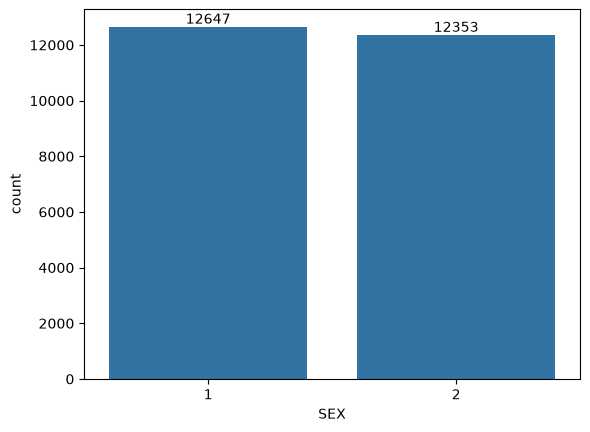

In [5]:
ax = sns.countplot(x = 'SEX', data = df)
for bars in ax.containers:
    ax.bar_label(bars)

# Covid Risk_Category Distribution Across Gender

<Axes: xlabel='RISK_CATEGORY', ylabel='count'>

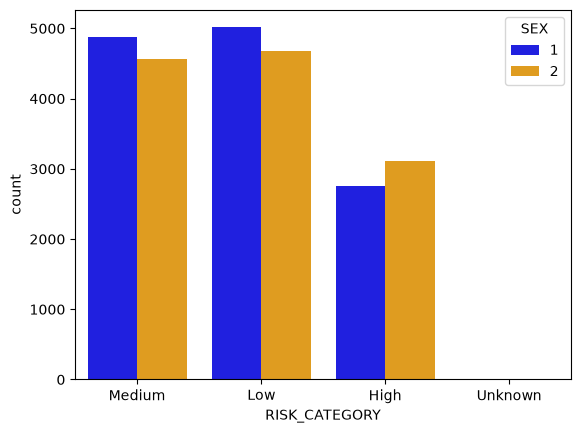

In [7]:
sns.countplot(x= 'RISK_CATEGORY', hue='SEX', data=df , palette= ['blue',  'orange'])

In [ ]:
# The graph indicates that Males were observed with high risk category than females.

# Covid Risk_Category with Asthma_Status among Gender

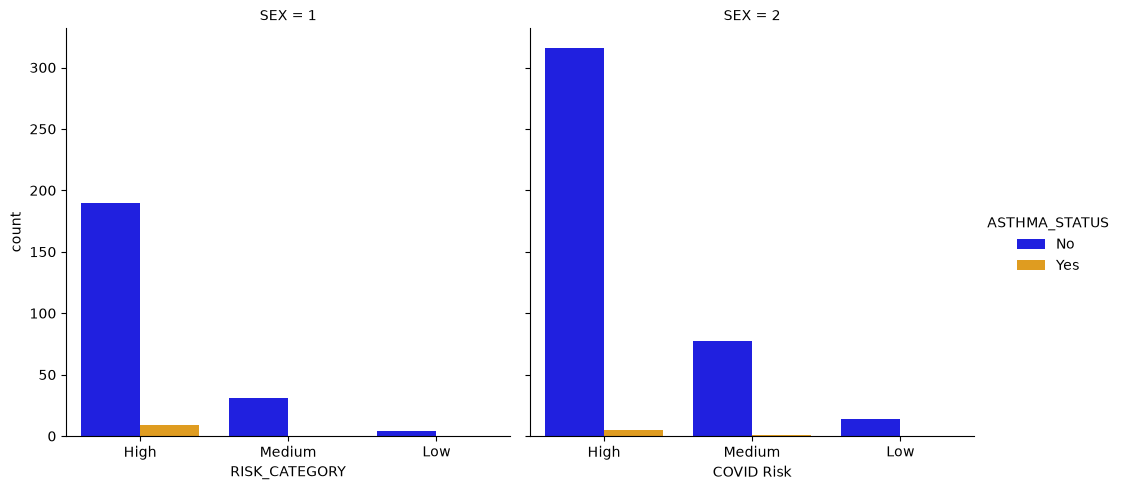

In [40]:
sns.catplot(data=df, x='RISK_CATEGORY', hue='ASTHMA_STATUS' , col = 'SEX' ,  kind ='count', palette= ['blue','orange'])
plt.xlabel('COVID Risk')
plt.ylabel('Number of Patients')
plt.show()

#  Covid Risk_Category with HYPERTENSION_Status among Patients

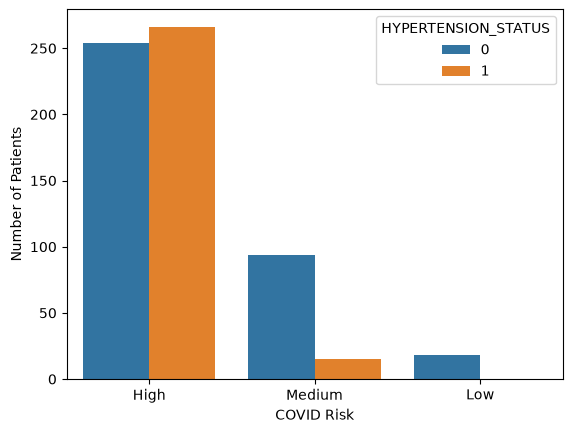

In [14]:
sns.countplot(data=df, x='RISK_CATEGORY', hue='HYPERTENSION_STATUS')
plt.xlabel('COVID Risk')
plt.ylabel('Number of Patients')
plt.show()

In [ ]:
# Patients with high covid risk category predominantly found with Hypertension status.

#  Covid Risk_Category with CARDIOVASCULAR_Status among Patients

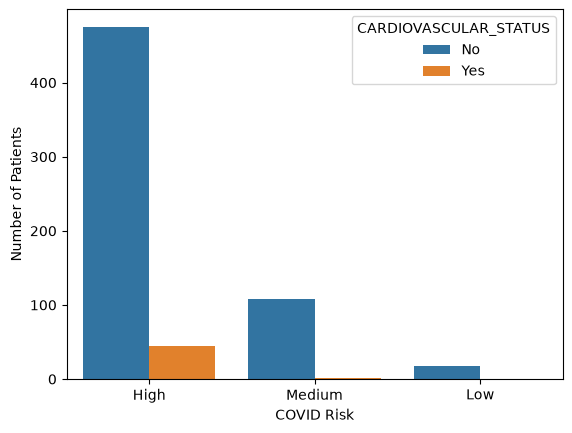

In [42]:
sns.countplot(data=df, x='RISK_CATEGORY', hue ='CARDIOVASCULAR_STATUS')
plt.xlabel('COVID Risk')
plt.ylabel('Number of Patients')
plt.show()

# Covid Risk_Category with COPD_Status among Patients

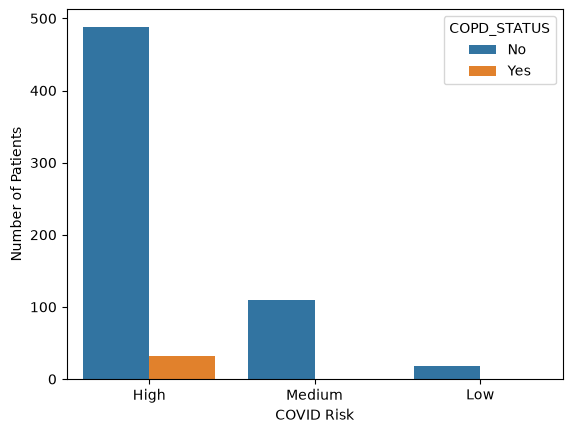

In [43]:
sns.countplot(data=df, x='RISK_CATEGORY', hue ='COPD_STATUS')
plt.xlabel('COVID Risk')
plt.ylabel('Number of Patients')
plt.show()

# Covid Risk_Category with RENAL_CHRONIC_Status among Patients

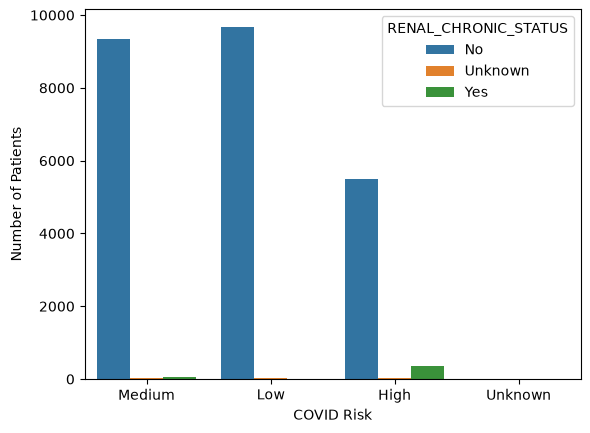

In [19]:
sns.countplot(data=df, x='RISK_CATEGORY', hue = 'RENAL_CHRONIC_STATUS')
plt.xlabel('COVID_Risk')
plt.ylabel('Number of Patients')
plt.show()

# Comparison of Health Conditions

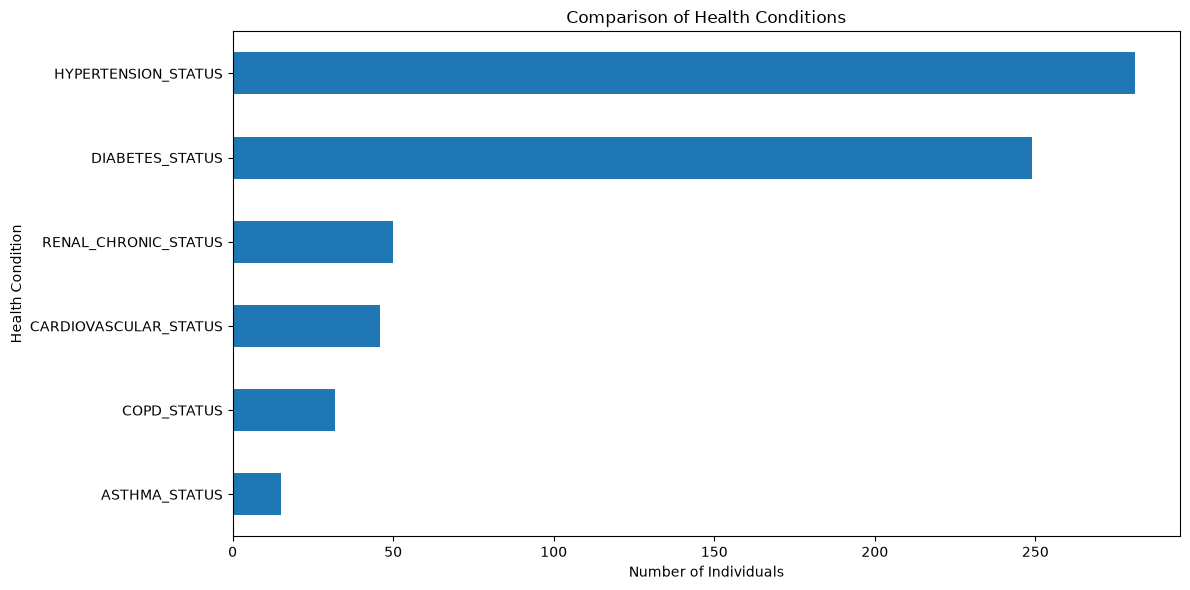

<Figure size 640x480 with 0 Axes>

In [55]:
risk_counts = df[[ "COPD_STATUS", "CARDIOVASCULAR_STATUS",  "ASTHMA_STATUS",  "RENAL_CHRONIC_STATUS","DIABETES_STATUS",
    "HYPERTENSION_STATUS"]].sum() 
plt.figure(figsize=(12, 6))
risk_counts.sort_values().plot(kind="barh")
plt.title("Comparison of Health Conditions")
plt.xlabel("Number of Individuals")
plt.ylabel("Health Condition")
plt.tight_layout()
plt.show()
# Save figure for GitHub
plt.savefig("Comparison of Health Conditions.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The above graph depicts that (250) highest number of patients observed with hypertension and less than 50 patients with Asthma status

# Correlation between Health Risk Factors

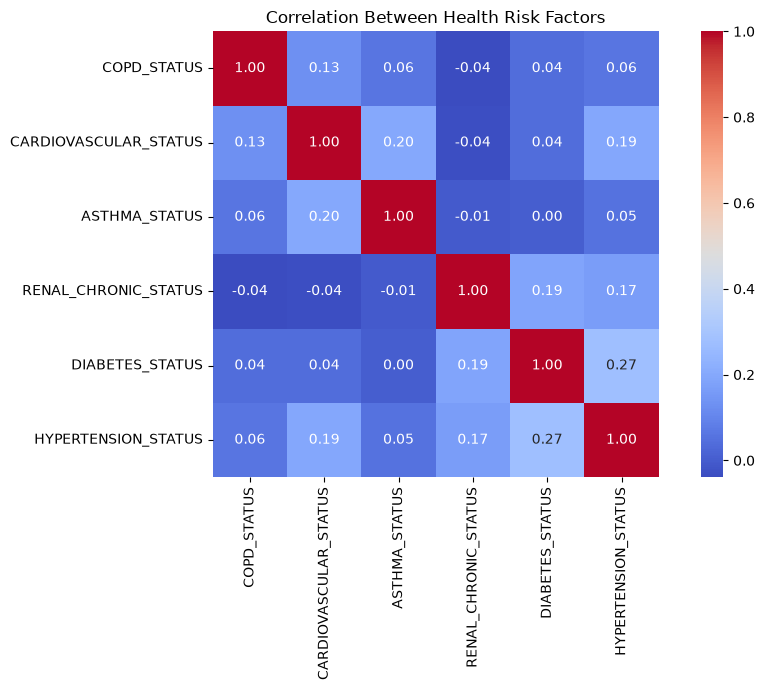

<Figure size 640x480 with 0 Axes>

In [52]:
risk_factors = [  "COPD_STATUS", "CARDIOVASCULAR_STATUS", "ASTHMA_STATUS", "RENAL_CHRONIC_STATUS",
 "DIABETES_STATUS",  "HYPERTENSION_STATUS"]
df_corr = df[risk_factors].replace({"Yes": 1, "No": 0})
correlation = df_corr.corr()
plt.figure(figsize=(10, 7))
sns.heatmap( correlation, annot=True,  fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Between Health Risk Factors")
plt.tight_layout()
plt.show()
# Save figure for GitHub
plt.savefig("Risk Factors_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The about Heatmap results show  no strong correlation between COPD, Cardiovascular, Hypertension, Diabetes, Renal-chronic and Asthma health conditions. 
#  COPD and Asthma = 0.06, both have very weak positive correlations with each other. 
#  Cardiovascular status and Hypertension = 0.19 ,both have very weak positive correlations with each other.
#  Asthma and Hypertension status = 0.05, both have very weak positive correlations with each other.
# Renal chronic status and Hypertension status = 0.17 , both have very weak positive correlations with each other.
# Diabetes and Hypertension status = 0.27 , both have very weak positive correlations with each other.
# hypertension status = 1.00 values shows that each variable correlated with itself.
# 